In [1]:
# # =========================================
# # 1. IMPORTS
# # =========================================
# import os
# import librosa
# import librosa.display
# import numpy as np
# import pandas as pd
# import torch
# import torch.nn as nn
# import matplotlib.pyplot as plt
# import seaborn as sns

# from torch.utils.data import Dataset, DataLoader
# from sklearn.preprocessing import LabelEncoder
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# from tqdm import tqdm


# # =========================================
# # 2. PATHS
# # =========================================
# DATA_PATH = r"C:\ML_MCA\wildlife-audio-project\data\train_audio"
# CSV_PATH = r"C:\ML_MCA\wildlife-audio-project\data\train.csv"


# # =========================================
# # 3. LOAD DATA
# # =========================================
# df = pd.read_csv(CSV_PATH)

# file_paths = []
# labels = []

# for _, row in df.iterrows():
#     filename = row["filename"]
#     label = row["primary_label"]

#     path = os.path.join(DATA_PATH, filename)

#     if os.path.exists(path):
#         file_paths.append(path)
#         labels.append(label)

# print("Loaded files:", len(file_paths))


# # =========================================
# # 🎯 VISUALIZATION 1: WAVEFORM
# # Shows raw audio signal
# # =========================================
# audio, sr = librosa.load(file_paths[0])

# plt.figure(figsize=(12,4))
# librosa.display.waveshow(audio, sr=sr)
# plt.title("Waveform (Audio Signal)")
# plt.show()


# # =========================================
# # 4. LABEL ENCODING
# # =========================================
# le = LabelEncoder()
# labels = le.fit_transform(labels)
# num_classes = len(set(labels))


# # =========================================
# # 🎯 VISUALIZATION 2: CLASS DISTRIBUTION
# # Shows dataset imbalance
# # =========================================
# label_names = le.inverse_transform(labels)

# pd.Series(label_names).value_counts().head(20).plot(kind='bar')
# plt.title("Top 20 Class Distribution")
# plt.show()


# # =========================================
# # 5. SPLIT DATA
# # =========================================
# train_paths, val_paths, train_labels, val_labels = train_test_split(
#     file_paths, labels, test_size=0.2, random_state=42
# )


# # =========================================
# # 🎯 VISUALIZATION 3: TRAIN VS VALIDATION
# # =========================================
# plt.bar(["Train", "Validation"], [len(train_paths), len(val_paths)])
# plt.title("Train vs Validation Split")
# plt.show()


# # =========================================
# # 6. AUDIO PROCESSING
# # =========================================
# def split_audio(file_path, duration=5, sr=32000):
#     audio, sr = librosa.load(file_path, sr=sr)
#     samples = sr * duration

#     segments = []
#     for start in range(0, len(audio), samples):
#         seg = audio[start:start+samples]
#         if len(seg) == samples:
#             segments.append(seg)

#     return segments


# def audio_to_mel(segment, sr=32000):
#     mel = librosa.feature.melspectrogram(y=segment, sr=sr, n_mels=128)
#     mel = librosa.power_to_db(mel)

#     # ✅ FIXED NORMALIZATION (NO NaN)
#     mel = (mel - np.mean(mel)) / (np.std(mel) + 1e-6)

#     return mel


# # =========================================
# # 🎯 VISUALIZATION 4: MEL SPECTROGRAM
# # =========================================
# seg = split_audio(file_paths[0])[0]
# mel = audio_to_mel(seg)

# plt.figure(figsize=(10,4))
# librosa.display.specshow(mel, sr=32000)
# plt.colorbar()
# plt.title("Mel Spectrogram")
# plt.show()


# # =========================================
# # 7. DATASET
# # =========================================
# class BirdDataset(Dataset):
#     def __init__(self, paths, labels):
#         self.paths = paths
#         self.labels = labels

#     def __len__(self):
#         return len(self.paths)

#     def __getitem__(self, idx):

#         segments = split_audio(self.paths[idx])

#         if len(segments) == 0:
#             seg = np.zeros(32000*5)
#         else:
#             # ✅ RANDOM SEGMENT (better learning)
#             seg = segments[np.random.randint(len(segments))]

#         mel = audio_to_mel(seg)

#         mel = torch.tensor(mel).unsqueeze(0).float()
#         label = torch.tensor(self.labels[idx])

#         return mel, label


# # =========================================
# # 8. DATALOADER
# # =========================================
# train_loader = DataLoader(BirdDataset(train_paths, train_labels), batch_size=8, shuffle=True)
# val_loader = DataLoader(BirdDataset(val_paths, val_labels), batch_size=8)


# # =========================================
# # 9. CNN14-STYLE MODEL
# # =========================================
# class CNN14(nn.Module):
#     def __init__(self, num_classes):
#         super().__init__()

#         self.conv = nn.Sequential(
#             nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
#             nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
#             nn.Conv2d(64,128,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
#             nn.Conv2d(128,256,3,padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d((1,1))
#         )

#         self.fc = nn.Linear(256, num_classes)

#     def forward(self,x):
#         x = self.conv(x)
#         x = x.view(x.size(0), -1)
#         return self.fc(x)


# model = CNN14(num_classes)

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = model.to(device)


# # =========================================
# # 10. TRAINING SETUP
# # =========================================
# criterion = nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)


# # =========================================
# # 11. TRAINING
# # =========================================
# EPOCHS = 5
# losses = []

# for epoch in range(EPOCHS):
#     model.train()
#     total_loss = 0

#     for x, y in tqdm(train_loader):
#         x, y = x.to(device), y.to(device)

#         out = model(x)
#         loss = criterion(out, y)

#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         total_loss += loss.item()

#     losses.append(total_loss)
#     print(f"Epoch {epoch+1} Loss: {total_loss:.3f}")


# # =========================================
# # 🎯 VISUALIZATION 5: LOSS CURVE
# # =========================================
# plt.plot(losses)
# plt.title("Training Loss Curve")
# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.show()


# # =========================================
# # 12. EVALUATION
# # =========================================
# y_true, y_pred = [], []

# model.eval()

# with torch.no_grad():
#     for x, y in val_loader:
#         x = x.to(device)

#         out = model(x)
#         preds = torch.argmax(out, 1)

#         y_true.extend(y.numpy())
#         y_pred.extend(preds.cpu().numpy())


# # =========================================
# # 13. ACCURACY + REPORT
# # =========================================
# acc = accuracy_score(y_true, y_pred)

# print("\nAccuracy:", round(acc*100,2), "%")
# print("\nClassification Report:\n")
# print(classification_report(y_true, y_pred))


# # =========================================
# # 🎯 VISUALIZATION 6: CONFUSION MATRIX
# # =========================================
# cm = confusion_matrix(y_true, y_pred)

# plt.figure(figsize=(8,6))
# sns.heatmap(cm, cmap="Blues")
# plt.title("Confusion Matrix")
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.show()

In [2]:
# =========================================
# 1. IMPORTS
# =========================================
import os
import librosa
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from tqdm import tqdm


# =========================================
# 2. PATHS
# =========================================
DATA_PATH = r"C:\ML_MCA\wildlife-audio-project\data\train_audio"
CSV_PATH = r"C:\ML_MCA\wildlife-audio-project\data\train.csv"


# =========================================
# 3. LOAD DATA
# =========================================
df = pd.read_csv(CSV_PATH)

# 🔥 Keep top 20 classes
top_classes = df["primary_label"].value_counts().head(20).index
df = df[df["primary_label"].isin(top_classes)]

file_paths, labels = [], []

for _, row in df.iterrows():
    path = os.path.join(DATA_PATH, row["filename"])
    if os.path.exists(path):
        file_paths.append(path)
        labels.append(row["primary_label"])

print("Loaded:", len(file_paths))


# =========================================
# 4. LABEL ENCODING
# =========================================
le = LabelEncoder()
labels = le.fit_transform(labels)
num_classes = len(set(labels))


# =========================================
# 5. TRAIN-TEST SPLIT
# =========================================
train_paths, val_paths, train_labels, val_labels = train_test_split(
    file_paths, labels, test_size=0.2, random_state=42
)


# =========================================
# 6. AUDIO FUNCTIONS
# =========================================
def split_audio(file_path, duration=5, sr=32000):
    audio, sr = librosa.load(file_path, sr=sr)
    samples = sr * duration

    segments = []
    for start in range(0, len(audio), samples):
        seg = audio[start:start+samples]
        if len(seg) == samples:
            segments.append(seg)

    # safety fallback
    if len(segments) == 0:
        segments.append(np.zeros(sr*duration))

    return segments


def audio_to_mel(segment):
    mel = librosa.feature.melspectrogram(y=segment, sr=32000, n_mels=128)
    mel = librosa.power_to_db(mel)

    # safe normalization
    mel = (mel - np.mean(mel)) / (np.std(mel) + 1e-6)

    return mel


# =========================================
# 7. DATASET (FIXED MULTI-SEGMENT)
# =========================================
class BirdDataset(Dataset):
    def __init__(self, paths, labels):
        self.paths = paths
        self.labels = labels

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):

        segments = split_audio(self.paths[idx])

        REQUIRED_SEGMENTS = 3

        # 🔥 FIX: always return 3 segments
        if len(segments) >= REQUIRED_SEGMENTS:
            idxs = np.random.choice(len(segments), REQUIRED_SEGMENTS, replace=False)
            segments = [segments[i] for i in idxs]
        else:
            segments = segments * (REQUIRED_SEGMENTS // len(segments) + 1)
            segments = segments[:REQUIRED_SEGMENTS]

        mels = []

        for seg in segments:
            mel = audio_to_mel(seg)

            mel = torch.tensor(mel).unsqueeze(0).float()
            mel = F.interpolate(mel.unsqueeze(0), size=(224,224)).squeeze(0)
            mel = mel.repeat(3,1,1)

            mels.append(mel)

        # shape: [3, 3, 224, 224]
        mels = torch.stack(mels)

        label = torch.tensor(self.labels[idx])

        return mels, label


# =========================================
# 8. DATALOADER
# =========================================
train_loader = DataLoader(BirdDataset(train_paths, train_labels), batch_size=8, shuffle=True)
val_loader = DataLoader(BirdDataset(val_paths, val_labels), batch_size=8)


# =========================================
# 9. MODEL (EfficientNet)
# =========================================
model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    num_classes
)

# 🔥 Partial fine-tuning
for param in model.features.parameters():
    param.requires_grad = False

for param in model.features[-1].parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


# =========================================
# 10. LOSS FUNCTION
# =========================================
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)


# =========================================
# 11. TRAINING
# =========================================
EPOCHS = 5

for epoch in range(EPOCHS):

    model.train()
    total_loss = 0

    for x, y in tqdm(train_loader):

        x, y = x.to(device), y.to(device)

        # reshape: [batch, segments, C, H, W]
        b, s, c, h, w = x.shape

        x = x.view(b*s, c, h, w)

        out = model(x)

        # reshape back
        out = out.view(b, s, -1).mean(dim=1)

        loss = criterion(out, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss: {total_loss:.2f}")


# =========================================
# 12. EVALUATION
# =========================================
y_true, y_pred = [], []

model.eval()

with torch.no_grad():
    for x, y in val_loader:

        x = x.to(device)

        b, s, c, h, w = x.shape
        x = x.view(b*s, c, h, w)

        out = model(x)
        out = out.view(b, s, -1).mean(dim=1)

        preds = torch.argmax(out, 1)

        y_true.extend(y.numpy())
        y_pred.extend(preds.cpu().numpy())


# =========================================
# 13. RESULTS
# =========================================
acc = accuracy_score(y_true, y_pred)

print("\n🔥 Accuracy:", round(acc*100,2), "%")
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

Loaded: 9843


100%|██████████| 985/985 [38:17<00:00,  2.33s/it]


Epoch 1 Loss: 2468.23


100%|██████████| 985/985 [36:00<00:00,  2.19s/it]


Epoch 2 Loss: 1968.86


...

Epoch 3 Loss: 1777.45


100%|██████████| 985/985 [35:54<00:00,  2.19s/it] 


Epoch 4 Loss: 1668.16


100%|██████████| 985/985 [33:36<00:00,  2.05s/it]


Epoch 5 Loss: 1576.29

🔥 Accuracy: 51.85 %

Classification Report:

              precision    recall  f1-score   support

           0       0.66      0.59      0.62       104
           1       0.49      0.42      0.45       101
           2       0.41      0.52      0.46       100
           3       0.44      0.50      0.47        98
           4       0.56      0.72      0.63        98
           5       0.52      0.82      0.64        89
           6       0.61      0.61      0.61       114
           7       0.49      0.60      0.54        81
           8       0.51      0.65      0.58       110
           9       0.44      0.35      0.39       105
          10       0.51      0.31      0.39        99
          11       0.63      0.61      0.62       109
          12       0.54      0.36      0.43       103
          13       0.71      0.20      0.31        76
          14       0.71      0.63      0.67        97
          15       0.54      0.53      0.54        98
          16 

Loaded files: 14334


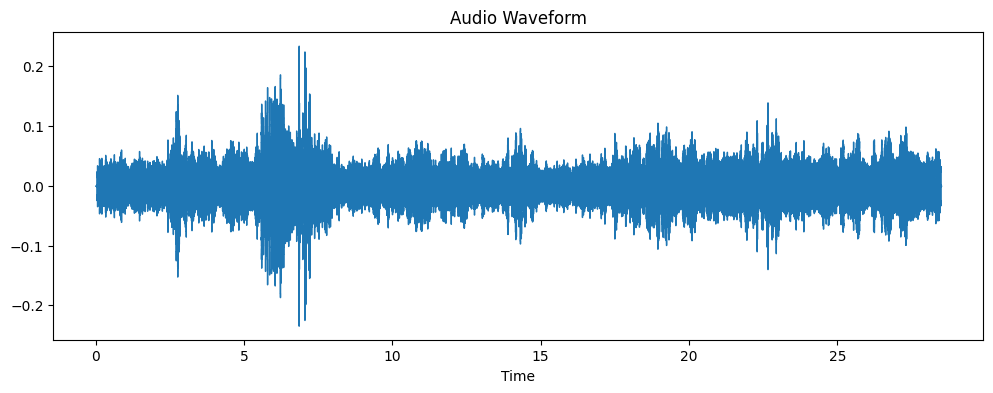

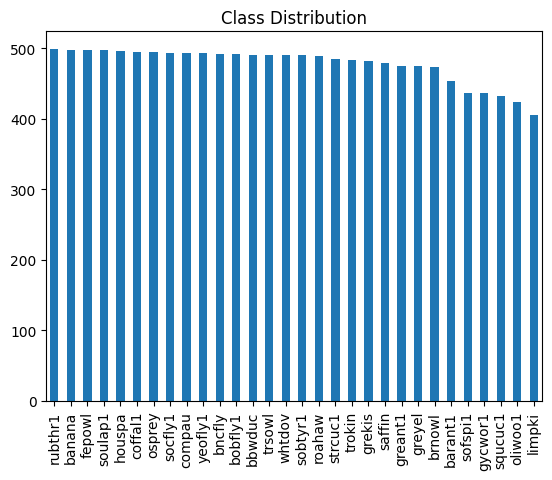

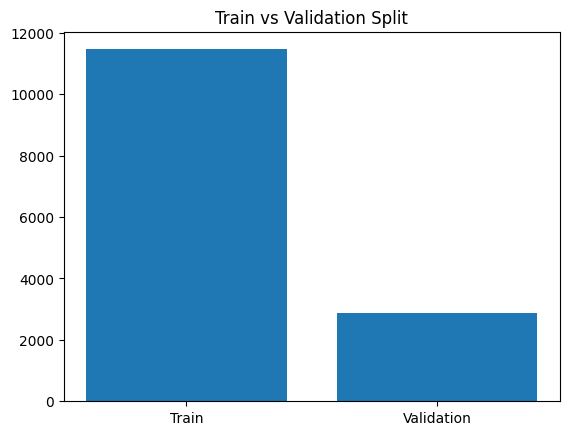

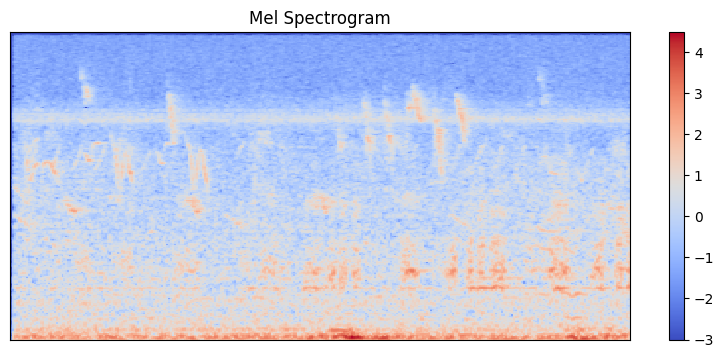

100%|██████████| 717/717 [1:08:16<00:00,  5.71s/it]


Epoch 1 Loss: 2203.976


100%|██████████| 717/717 [43:14<00:00,  3.62s/it]  


Epoch 2 Loss: 1905.967


100%|██████████| 717/717 [42:40<00:00,  3.57s/it]


Epoch 3 Loss: 1796.812


100%|██████████| 717/717 [49:42<00:00,  4.16s/it]  


Epoch 4 Loss: 1721.454


100%|██████████| 717/717 [49:21<00:00,  4.13s/it]  


Epoch 5 Loss: 1675.139


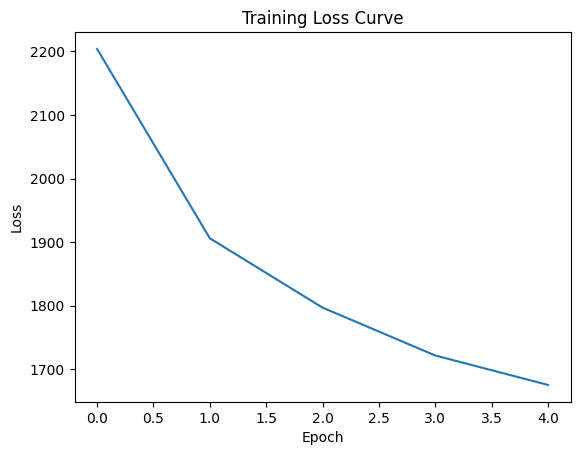


🔥 Accuracy: 37.53 %

Classification Report:

              precision    recall  f1-score   support

           0       0.38      0.40      0.39       108
           1       0.51      0.29      0.37        89
           2       0.42      0.36      0.39       101
           3       0.29      0.23      0.26        92
           4       0.33      0.28      0.30       106
           5       0.17      0.44      0.25        88
           6       0.62      0.36      0.45       103
           7       0.40      0.61      0.48       104
           8       0.57      0.42      0.48       110
           9       0.48      0.38      0.42       100
          10       0.48      0.32      0.39        93
          11       0.22      0.32      0.26       102
          12       0.55      0.65      0.59        85
          13       0.30      0.58      0.39        83
          14       0.37      0.53      0.44        72
          15       0.30      0.52      0.38        87
          16       0.27      0.37  

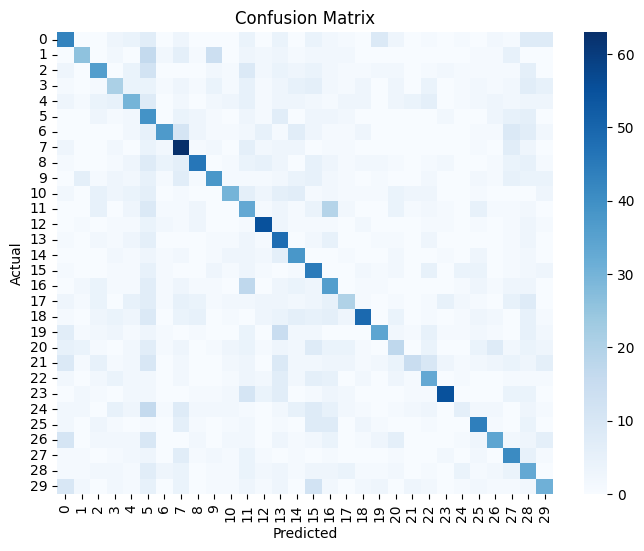

In [4]:
# =========================================
# 1. IMPORTS
# =========================================
import os
import librosa
import librosa.display
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights


# =========================================
# 2. PATHS
# =========================================
DATA_PATH = r"C:\ML_MCA\wildlife-audio-project\data\train_audio"
CSV_PATH = r"C:\ML_MCA\wildlife-audio-project\data\train.csv"


# =========================================
# 3. LOAD DATA
# =========================================
df = pd.read_csv(CSV_PATH)

# 🔥 KEEP TOP 30 CLASSES ONLY (IMPORTANT)
top_classes = df["primary_label"].value_counts().head(30).index
df = df[df["primary_label"].isin(top_classes)]

file_paths = []
labels = []

for _, row in df.iterrows():
    filename = row["filename"]
    label = row["primary_label"]

    path = os.path.join(DATA_PATH, filename)

    if os.path.exists(path):
        file_paths.append(path)
        labels.append(label)

print("Loaded files:", len(file_paths))


# =========================================
# 🎯 VISUALIZATION 1: WAVEFORM
# =========================================
audio, sr = librosa.load(file_paths[0])

plt.figure(figsize=(12,4))
librosa.display.waveshow(audio, sr=sr)
plt.title("Audio Waveform")
plt.show()


# =========================================
# 4. LABEL ENCODING
# =========================================
le = LabelEncoder()
labels = le.fit_transform(labels)
num_classes = len(set(labels))


# =========================================
# 🎯 VISUALIZATION 2: CLASS DISTRIBUTION
# =========================================
label_names = le.inverse_transform(labels)

pd.Series(label_names).value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.show()


# =========================================
# 5. SPLIT DATA
# =========================================
train_paths, val_paths, train_labels, val_labels = train_test_split(
    file_paths, labels, test_size=0.2, random_state=42
)

plt.bar(["Train", "Validation"], [len(train_paths), len(val_paths)])
plt.title("Train vs Validation Split")
plt.show()


# =========================================
# 6. AUDIO PROCESSING
# =========================================
def split_audio(file_path, duration=5, sr=32000):
    audio, sr = librosa.load(file_path, sr=sr)
    samples = sr * duration

    segments = []
    for start in range(0, len(audio), samples):
        seg = audio[start:start+samples]
        if len(seg) == samples:
            segments.append(seg)

    return segments


def add_noise(x):
    return x + 0.003*np.random.randn(len(x))


def audio_to_mel(segment, sr=32000):
    mel = librosa.feature.melspectrogram(y=segment, sr=sr, n_mels=224)
    mel = librosa.power_to_db(mel)

    mel = (mel - np.mean(mel)) / (np.std(mel) + 1e-6)

    return mel


# =========================================
# 🎯 VISUALIZATION 3: MEL SPECTROGRAM
# =========================================
seg = split_audio(file_paths[0])[0]
mel = audio_to_mel(seg)

plt.figure(figsize=(10,4))
librosa.display.specshow(mel, sr=32000)
plt.colorbar()
plt.title("Mel Spectrogram")
plt.show()


# =========================================
# 7. DATASET
# =========================================
class BirdDataset(Dataset):
    def __init__(self, paths, labels):
        self.paths = paths
        self.labels = labels

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):

        segments = split_audio(self.paths[idx])

        if len(segments) == 0:
            seg = np.zeros(32000*5)
        else:
            seg = segments[np.random.randint(len(segments))]

        seg = add_noise(seg)

        mel = audio_to_mel(seg)

        mel = torch.tensor(mel).unsqueeze(0).float()

        mel = F.interpolate(mel.unsqueeze(0), size=(224,224)).squeeze(0)

        mel = mel.repeat(3,1,1)

        label = torch.tensor(self.labels[idx])

        return mel, label


# =========================================
# 8. DATALOADER
# =========================================
train_loader = DataLoader(BirdDataset(train_paths, train_labels), batch_size=16, shuffle=True)
val_loader = DataLoader(BirdDataset(val_paths, val_labels), batch_size=16)


# =========================================
# 9. MODEL (EfficientNet)
# =========================================
model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    num_classes
)

# 🔥 PARTIAL FREEZE (IMPORTANT)
for param in model.features.parameters():
    param.requires_grad = False

for param in model.features[-1].parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


# =========================================
# 10. CLASS WEIGHTS (IMPORTANT)
# =========================================
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)


# =========================================
# 11. TRAINING
# =========================================
EPOCHS = 5
losses = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for x, y in tqdm(train_loader):
        x, y = x.to(device), y.to(device)

        out = model(x)
        loss = criterion(out, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    losses.append(total_loss)
    print(f"Epoch {epoch+1} Loss: {total_loss:.3f}")


# =========================================
# 🎯 VISUALIZATION 4: LOSS CURVE
# =========================================
plt.plot(losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


# =========================================
# 12. EVALUATION
# =========================================
y_true, y_pred = [], []

model.eval()

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)

        out = model(x)
        preds = torch.argmax(out, 1)

        y_true.extend(y.numpy())
        y_pred.extend(preds.cpu().numpy())


# =========================================
# 13. RESULTS
# =========================================
acc = accuracy_score(y_true, y_pred)

print("\n🔥 Accuracy:", round(acc*100,2), "%")

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))


# =========================================
# 🎯 VISUALIZATION 5: CONFUSION MATRIX
# =========================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()